<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [2]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [4]:
## Write your code here

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 195.7 MB

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [5]:
## Write your code here
df.isnull().sum()


ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64

### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [6]:
## Write your code here
print(df['Employment'].value_counts())
print(df['JobSat'].value_counts())
print(df['YearsCodePro'].value_counts())

Employment
Employed, full-time                                                                                                                                   39041
Independent contractor, freelancer, or self-employed                                                                                                   4846
Student, full-time                                                                                                                                     4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                                                                                                     2341
                                                                                                                                                      ...  
Not employed, but looking for work;Independent contra

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


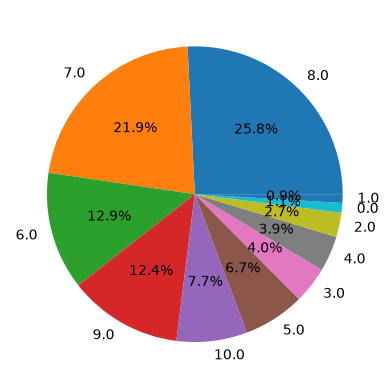

In [7]:
## Write your code here
df['JobSat'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()


### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


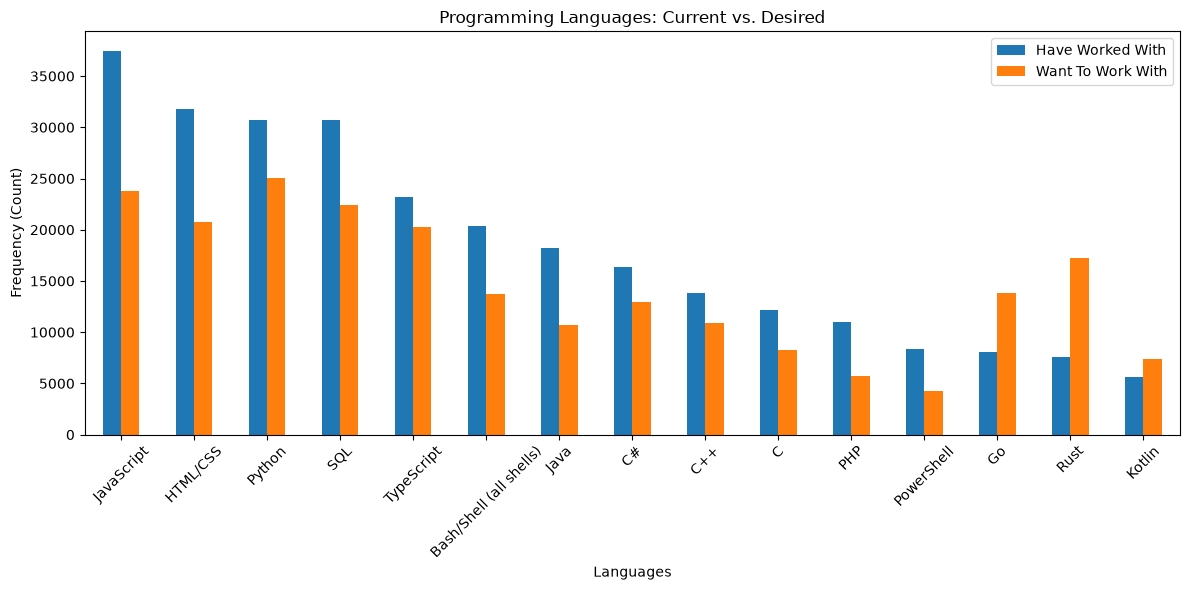

In [8]:
## Write your code here


# 1. Split and count individual languages for both columns
have_worked = (
    df["LanguageHaveWorkedWith"].str.split(";").explode().value_counts()
)
want_to_work = (
    df["LanguageWantToWorkWith"].str.split(";").explode().value_counts()
)

# 2. Combine the counts into a single DataFrame for comparison
lang_df = pd.DataFrame(
    {"Have Worked With": have_worked, "Want To Work With": want_to_work}
).fillna(0)

# 3. Sort by popularity and select the top 15 languages
lang_df = lang_df.sort_values(by="Have Worked With", ascending=False).head(15)

# 4. Plot a grouped bar chart
lang_df.plot(kind="bar", figsize=(12, 6))
plt.title("Programming Languages: Current vs. Desired")
plt.xlabel("Languages")
plt.ylabel("Frequency (Count)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


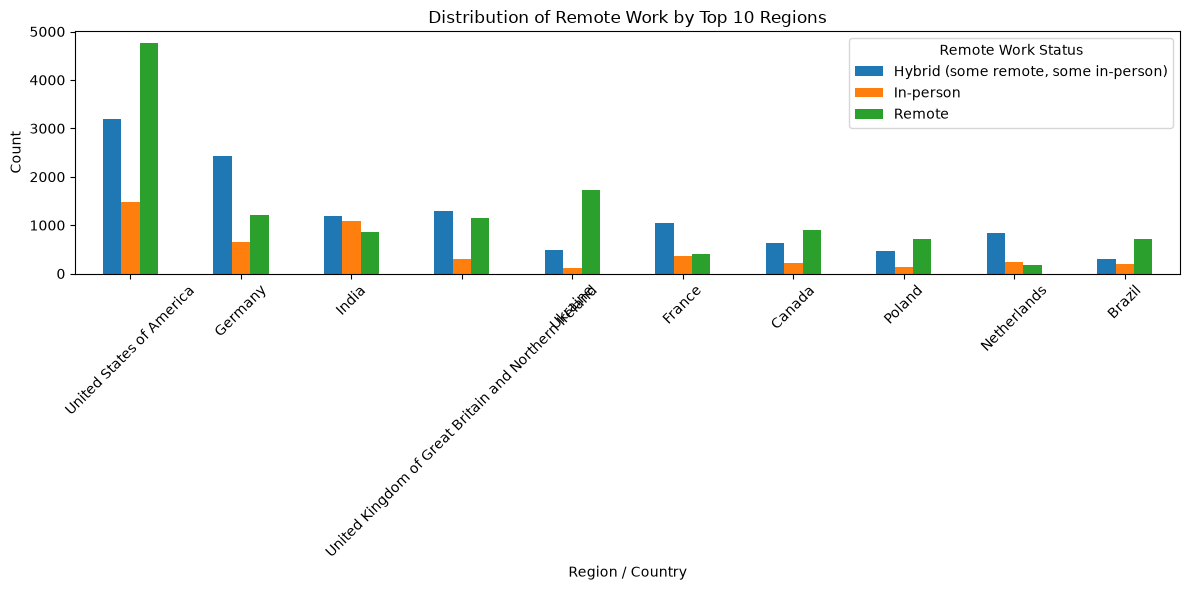

In [9]:
## Write your code here
remote_region = pd.crosstab(df["Country"], df["RemoteWork"])

# 2. Filter for the top 10 regions to keep the chart clean
top_regions = df["Country"].value_counts().head(10).index
remote_region_filtered = remote_region.loc[top_regions]

# 3. Plot the grouped bar chart
remote_region_filtered.plot(kind="bar", figsize=(12, 6))
plt.title("Distribution of Remote Work by Top 10 Regions")
plt.xlabel("Region / Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Remote Work Status")
plt.tight_layout()
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [10]:
## Write your code here
# 1. Ensure 'YearsCodePro' is numeric (coercing errors to NaN)
df["YearsCodePro"] = pd.to_numeric(df["YearsCodePro"], errors="coerce")

# 2. Optional: Convert JobSat to numerical scores if it's text-based
# Check your dataset unique values for JobSat first. Here is a typical mapping:
sat_mapping = {
    "Very satisfied": 5,
    "Slightly satisfied": 4,
    "Neither satisfied nor dissatisfied": 3,
    "Slightly dissatisfied": 2,
    "Very dissatisfied": 1,
}
# Map it if it's currently text. If it's already numbers, skip this line:
df["JobSat_Numeric"] = df["JobSat"].map(sat_mapping)

# 3. Calculate the correlation coefficient
# Using 'spearman' handles ordinal satisfaction scores well
correlation = df["JobSat_Numeric"].corr(df["YearsCodePro"], method="spearman")
print(f"Spearman correlation between JobSat and YearsCodePro: {correlation:.4f}")


Spearman correlation between JobSat and YearsCodePro: nan

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


/tmp/ipykernel_879/3198790822.py:14: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()

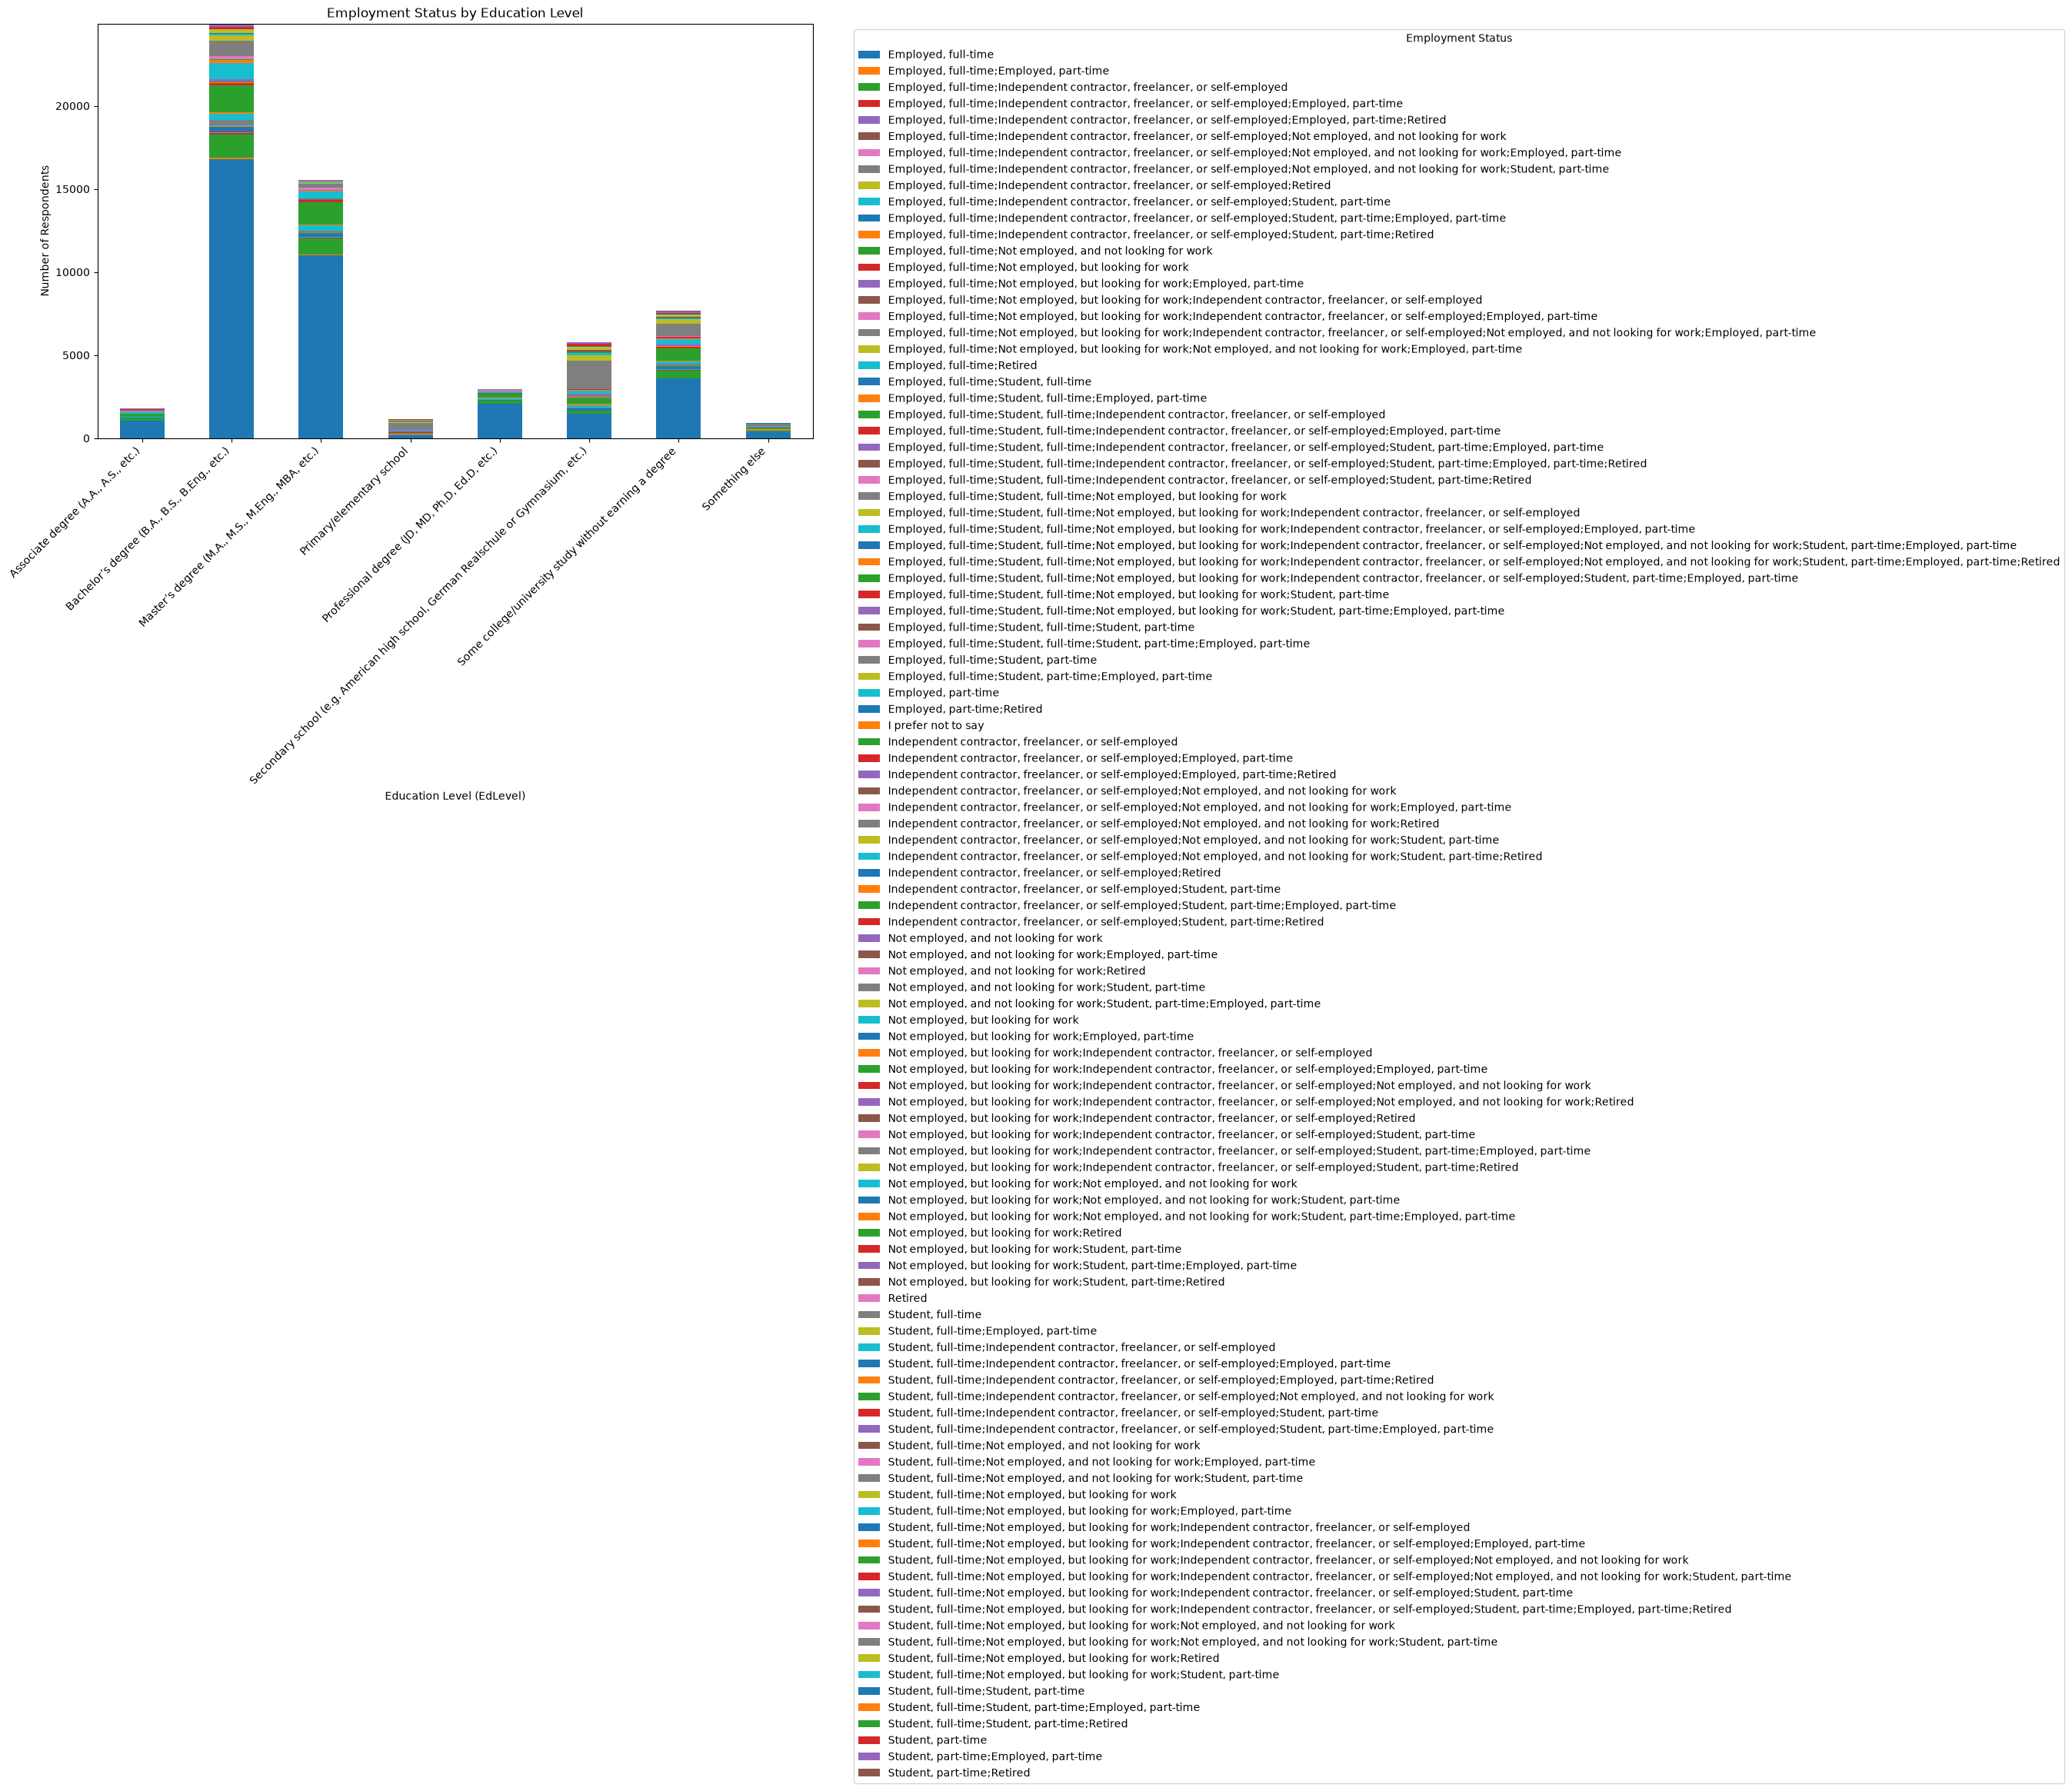

In [11]:
## Write your code here
# 1. Generate the cross-tabulation matrix
emp_edu_cross = pd.crosstab(df["EdLevel"], df["Employment"])

# 2. Plot as a stacked bar chart
emp_edu_cross.plot(kind="bar", stacked=True, figsize=(12, 7))
plt.title("Employment Status by Education Level")
plt.xlabel("Education Level (EdLevel)")
plt.ylabel("Number of Respondents")
plt.xticks(
    rotation=45, ha="right"
)  # Rotates and aligns the labels neatly
plt.legend(title="Employment Status", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [12]:
## Write your code here
# Save the cleaned dataset
df.to_csv("Cleaned_StackOverflow_Data.csv", index=False)
print("Dataset successfully exported to 'Cleaned_StackOverflow_Data.csv'")


Dataset successfully exported to 'Cleaned_StackOverflow_Data.csv'

### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
